In [3]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam



In [12]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   # dependendo da versão do NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jose.sales\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jose.sales\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jose.sales\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jose.sales\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\jose.sales\AppData\Roaming\nltk_data...


True

In [13]:
df = pd.read_csv("IMDB Dataset.csv")

In [14]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [15]:
teste = 1

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [17]:
def preprocess(text):
    text = re.sub(r'\\', '', text)
    text = contractions.fix(text)

    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[\d\W]+', ' ', text)
    text = re.sub(r'\s{2,}', ' ', text)
    text = text.strip()

    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    tokens = [token for token in tokens if token not in stop_words]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = [t for t in tokens if len(t) >= 3]

    return " ".join(tokens)

In [18]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

'I do try not to take IMDb ratings to heart, but I was flabbergasted when I saw the 5.4 rating to one of my childhood favourites. It doesn\'t wow me as much at 17, but as a family film this is a sweet and well meaning movie. Kids will definitely love it and won\'t mind the flaws, and the adults can guess the actor behind each character and admire the subliminal messaging of the film. None of the film was preachy in any way, in fact it has a great message that added to its sweetness. I will admit though that the story is on the thin side, and some scenes like Screweyes\'s death(which still freaks me out) may be a tad on the scary side. But the animation is well above average with nice colours and good character animation. The music by James Horner is very beautiful, and the song featured is memorable, catchy and amusing. I really liked the characters, Louie is probably the most in-depth of them all, but the dinosaurs were at least engaging. Martin Short\'s clown was both hilarious and e

In [19]:
print(preprocess(df.iloc[random_num]['review']))

try take imdb rating heart flabbergasted saw rating one childhood favourite wow much family film sweet well meaning movie kid definitely love mind flaw adult guess actor behind character admire subliminal messaging film none film preachy way fact great message added sweetness admit though story thin side scene like screweyes death still freak may tad scary side animation well average nice colour good character animation music james horner beautiful song featured memorable catchy amusing really liked character louie probably depth dinosaur least engaging martin short clown hilarious emphatic part tell screweyes quit stitch favourite screweyes though effective villain crafty suppose intelligent anything though wish film kept part explains lost eye scared crow way could developed term depth script oscar worthy funny heart warming part keep kid adult entertained voice acting made movie john goodman martin short rhea perlman felicity kendall yeardley smith gave solid performance special men

In [20]:
df['review'] = df['review'].apply(preprocess)

In [21]:
df

,review,sentiment
0,one reviewer mentioned watching episode hooked...,positive
1,wonderful little production filming technique ...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically family little boy jake think zombie ...,negative
4,petter mattei love time money visually stunnin...,positive
...,...,...
49995,thought movie right good job creative original...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,catholic taught parochial elementary school nu...,negative
49998,going disagree previous comment side maltin on...,negative


In [22]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [24]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [25]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [26]:
max_len = 150

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [54]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=64))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add(Bidirectional(LSTM(64, return_sequences=True, dropout=0.3)))
lstm_model.add(Bidirectional(LSTM(32, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 150, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 150, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,389,377 (5.30 MB)

 Trainable params: 1,389,377 (5.30 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [56]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/5


250/250 ━━━━━━━━━━━━━━━━━━━━ 84s 327ms/step - accuracy: 0.7110 - loss: 0.5254 - val_accuracy: 0.8723 - val_loss: 0.3072 - learning_rate: 5.0000e-04
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 102s 409ms/step - accuracy: 0.9000 - loss: 0.2715 - val_accuracy: 0.8811 - val_loss: 0.2831 - learning_rate: 5.0000e-04
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 91s 365ms/step - accuracy: 0.9333 - loss: 0.1934 - val_accuracy: 0.8816 - val_loss: 0.3035 - learning_rate: 5.0000e-04


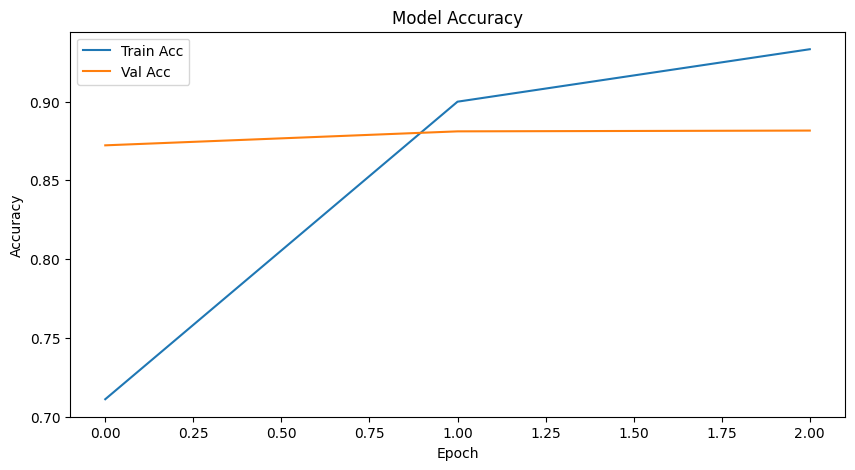

In [57]:
plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [58]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8869 - loss: 0.2643
Test Accuracy: 0.886900007724762


## Confusion Matrices

In [59]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step


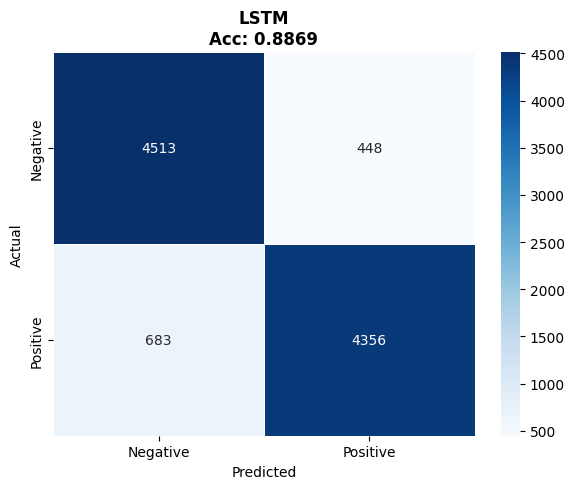

In [60]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

## Classification Reports

In [64]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.87      0.91      0.89      4961
    Positive       0.91      0.86      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [65]:

from keras.models import Model


In [78]:
import tensorflow as tf

dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

In [80]:
import tensorflow as tf
from keras.models import Model
import numpy as np

# força o modelo a ser chamado
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

# modelo de inspeção
layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

# entrada exemplo
x = np.random.randint(0, vocab_size, size=(1, max_len))

# forward
outputs = inspection_model.predict(x)

# salva em txt
with open("layer_outputs.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Outputs salvos em layer_outputs.txt
